<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 > OBSERVACIONES Y MEJORAS DE TESIS</strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  12/08/2026 - UPDATE FINAL</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2026</strong></p>
</div>

---

# **1. PRIMERO: Mapa generarl de todas las observaciones:**
Tenemos dos fuentes:

**Dr. Yuri**

Observaciones generales y apuntan principalmente a:

1. Buscar empresas potencialmente interesadas/compradoras.
2. Sustentar que las pruebas realizadas son las mejores.
3. Fortalecer la bibliografía sobre series de tiempo y LSTM.
4. Organizar y consolidar la bibliografía.
5. Construir una línea de tiempo.
6. Sustentar por qué se utiliza LSTM.
7. Sustentar matemáticamente la interpolación.
8. Precisar tipo de datos.
9. Precisar modelo.
10. Precisar análisis de datos.
11. Sustentar bibliográficamente la resolución.
12. Incorporar anexo de resultados.
13. Incorporar tablas comparativas de pruebas de modelos y variaciones de parámetros.

**Dr. Marcos Alania**

Observaciones  específicas y metodológicamente críticas:

1. Data leakage / fuga de información.
2. Cambiar a validación Out-of-Time.
3. Actualizar estado del arte 2022–2026.
4. Incorporar al menos un Transformer para series temporales.
5. Incorporar modelo de persistencia.
6. Realizar ablation studies.
7. Justificar α = 2 y β = 50.
8. Analizar falsas alarmas.
9. Demostrar qué ocurre con ROTI y S4.
10. Incorporar Feature Importance o saliency.
11. Incorporar pruebas estadísticas.
12. Revisar inconsistencias temporales.
13. Comparar latencia y Recall.
14. Justificar la elección final de LSTM frente a Transformer.


# **1. RESOLVER EL DATA LEAKAGE**

El Dr. Marcos detectó que en la tesis se menciona un **“muestreo estratificado”** para generar el Test Set, algo peligroso en forecasting temporal porque puede mezclar información del futuro con el pasado.

Esto es lo primero que debemos revisar.

**ETAPA 1**

**0. LIBRERIAS**

In [23]:
# =============================================================================
# MODULO DE PREPROCESAMIENTO PARA CINTILACIONES IONOSFÉRICAS
# Autor: Alexander Valdez Portocarrero
# Descripción: Carga, análisis exploratorio y preparación de tensores para LSTM
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os,gc
import tensorflow as tf # Solo si necesitas verificar GPU aquí
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importaciones específicas de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Intentar importar seaborn para un mejor heatmap, si no, usamos matplotlib plano
try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False

In [24]:
# VERIFICAR TensorFlow
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("\nGPUs detectadas:")
print(tf.config.list_physical_devices('GPU'))

print("\n¿CUDA disponible?")
print(len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.19.0

GPUs detectadas:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

¿CUDA disponible?
True


**1. Carga de Datos**

In [25]:
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)

    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])

    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

**2. Analisis Exploratorio(EDA)**

In [26]:
def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """
    Analiza y visualiza los días con presencia de cintilación.
    No modifica el DF original permanentemente, solo reporta estadísticas.
    """
    print("\n🔍 Analizando distribución de eventos...")

    # Trabajamos con una copia ligera para no alterar el original
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date

    # 1. Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    resumen_diario = resumen_diario.reset_index()
    resumen_diario.columns = ["Fecha", "Evento_Cintilacion"] # True/False

    total_dias = resumen_diario["Fecha"].nunique()
    dias_con_evento = resumen_diario["Evento_Cintilacion"].sum()

    print(f"   Total de días registrados: {total_dias}")
    print(f"   Días con eventos (S4 > {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje de actividad: {(dias_con_evento/total_dias)*100:.2f}%")

    # 2. Reporte Mensual
    df_analisis["Mes"] = df_analisis["Tiempo"].dt.to_period("M")

    # Unimos para saber qué día tuvo evento
    # Primero agrupamos por día para saber si ESE día hubo evento
    max_s4_dia = df_analisis.groupby(["Mes", "Fecha"])["S4"].max().reset_index()
    max_s4_dia["Tuvo_Evento"] = (max_s4_dia["S4"] > umbral_s4).astype(int)

    # Tabla resumen
    tabla_mensual = max_s4_dia.groupby("Mes")["Tuvo_Evento"].agg(
        Dias_Con_Cintilacion='sum',
        Total_Dias='count'
    )
    tabla_mensual["Dias_Sin_Cintilacion"] = tabla_mensual["Total_Dias"] - tabla_mensual["Dias_Con_Cintilacion"]

    print("\n📊 Resumen Mensual de Actividad:")
    print(tabla_mensual)

    # 3. Visualización (Opcional)
    if plot:
        plt.figure(figsize=(12, 5))
        # Convertimos a string para que matplotlib no haga lío con fechas
        fechas_str = resumen_diario["Fecha"].astype(str)
        valores = resumen_diario["Evento_Cintilacion"].astype(int)

        plt.bar(fechas_str, valores, color=np.where(valores==1, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.ylabel("Presencia (1=Sí, 0=No)")
        plt.xticks(rotation=90, fontsize=8)

        # Mostrar solo una etiqueta cada 7 días para no saturar
        ax = plt.gca()
        for index, label in enumerate(ax.xaxis.get_ticklabels()):
            if index % 7 != 0:
                label.set_visible(False)

        plt.tight_layout()
        plt.show()

**3. FEATURE ENIGNEERING**

In [27]:
# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """
    Agrega transformaciones cíclicas de tiempo (Seno/Coseno).
    """
    print("\n⚙️ Generando características temporales (Sin/Cos)...")

    # Calcular minuto del día (0–1439)
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 # 1440 minutos

    # Transformación
    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)

    return df

**RESULTADOS Y EVALUACION**

**NOTA**

**CASO 1**

RUTA : /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
Trabajamos con el archivo: DF_FINAL_JICAMARCA_31072026.csv
📂 Cargando archivo: DF_FINAL_JICAMARCA_31072026.csv...
✅ Dataset cargado. Shape: (696090, 14)
   Rango de fechas: 2025-01-26 00:35:00 a 2026-07-21 22:45:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 512
   Días con eventos (S4 > 0.6): 97
   Porcentaje de actividad: 18.95%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    15          26                    11
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                     0          31                    31
2025-06                     0          27                    27
2025-07                 

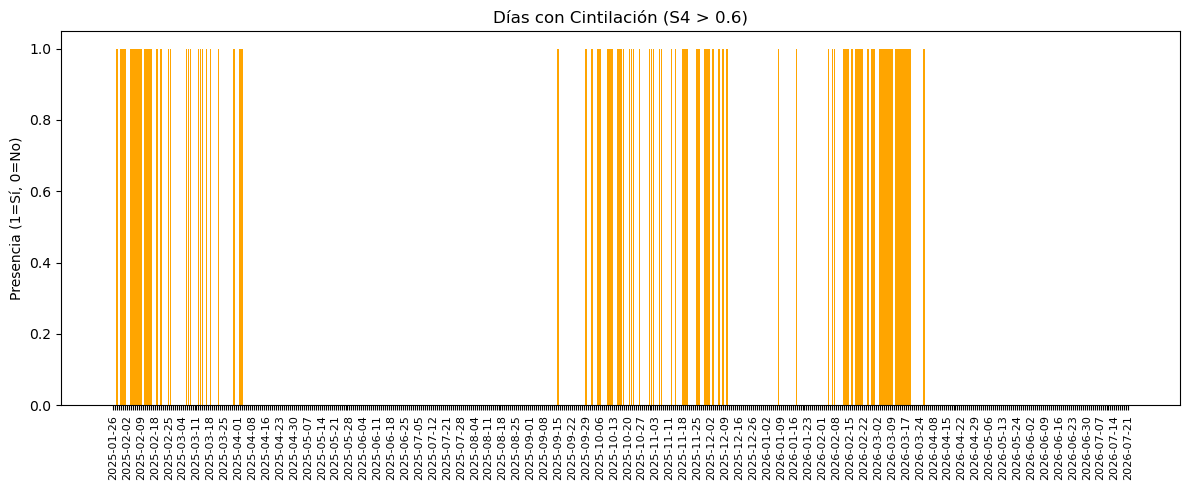


⚙️ Generando características temporales (Sin/Cos)...


In [61]:
if __name__ == "__main__":
    #1. Configuracion
    N_ESTACION = 0 # Escoge la estación
    ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
    RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO     = f"DF_FINAL_{ESTACION[N_ESTACION]}_{31072026}.csv"
    print("="*60)
    #print(f"RUTA DRIVE: {RUTA_DRIVE}")
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)
    # Definición de Features para el modelo (Orden Importante)
    FEATURES_COLS = [
        'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
        'Hora_Sin', 'Hora_Cos','S4',
    ]
    # 2. Pipeline de ejecución
    # Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    # Analizar (No modifica df_raw)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=True)

    # Ingeniería de Features (Modifica df_raw)
    df_features = agregar_caracteristicas_temporales(df_raw)

In [62]:
df_features.head()

,Tiempo,ID_Satelite,Azimuth,Elevacion,Estacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4,Hora_Sin,Hora_Cos
0,2025-01-26 00:35:00,39.0,189.0,31.0,JICAMARCA,70.689140,-0.012351,0.010958,3.0,-1.416667,2.0,165.4,29.083333,0.161,0.152123,0.988362
1,2025-01-26 00:36:00,39.0,189.0,32.0,JICAMARCA,70.778647,-0.010967,0.010961,3.0,-1.400000,2.0,165.4,29.000000,0.122,0.156434,0.987688
2,2025-01-26 00:37:00,13.0,197.0,32.0,JICAMARCA,70.868153,-0.009583,0.010964,3.0,-1.383333,2.0,165.4,28.916667,0.128,0.160743,0.986996
3,2025-01-26 00:38:00,39.0,189.0,33.0,JICAMARCA,70.957660,-0.008198,0.010966,3.0,-1.366667,2.0,165.4,28.833333,0.106,0.165048,0.986286
4,2025-01-26 00:39:00,13.0,196.0,32.0,JICAMARCA,71.047166,-0.006814,0.010969,3.0,-1.350000,2.0,165.4,28.750000,0.103,0.169350,0.985556


**ETAPA 2**

**4. Preparación final de estructura**

In [63]:
def finalizar_estructura_df(df, target_col="S4"):
    """
    Limpia columnas auxiliares, reordena y establece el índice temporal.
    Esta función deja el DF listo para entrar al Generador de Ventanas.
    """
    print("\n🧹 Finalizando estructura del DataFrame...")

    # 1. Asegurar índice temporal
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')

    df = df.sort_index()

    # 2. Reordenar columnas: Target al final (práctica estándar)
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    df = df[cols]

    # 3. Eliminar columnas que ya no sirven para el modelo numérico
    # (Ej: Fechas string, columnas categóricas, etc.)
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    # Borramos solo si existen
    cols_existentes = [c for c in cols_a_borrar if c in df.columns]

    if cols_existentes:
        df = df.drop(columns=cols_existentes)
        print(f"   Columnas eliminadas: {cols_existentes}")

    print(f"✅ DataFrame Final Listo. Shape: {df.shape}")
    print(f"   Columnas finales: {df.columns.tolist()}")

    return df

**5. ESTRATEGIA DE DIVISIÓN DE DATOS -DATASPLITTING**

In [64]:
# =============================================================================
# 5. ESTRATEGIA DE DIVISIÓN DE DATOS (DATA SPLITTING)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    """
    Divide el dataset asegurando que haya días con tormentas en Train, Val y Test.
    Mantiene la integridad interna de cada día completo.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")

    # Recuperamos la fecha del índice de forma segura
    fechas_unicas = np.unique(df.index.date)
    
    # Crear un DataFrame temporal de mapeo diario para calcular máximos de S4
    temp_diario = pd.DataFrame(index=df.index)
    temp_diario['Fecha'] = df.index.date
    temp_diario['S4'] = df['S4'].values
    
    resumen_diario = temp_diario.groupby('Fecha')['S4'].max().reset_index()

    # Identificar DIAS ACTIVOS  vs DIAS QUIETOS
    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    
    print("-------- Distribución Original de Días ------------")
    print(f"   Total Días Activos encontrados: {len(dias_activos)}")
    print(f"   Total Días Quietos encontrados: {len(dias_quietos)}")
    # Opcional: Si deseas aplicar el submuestreo de días quietos que tenías comentado:
    dias_quietos = dias_quietos[:len(dias_activos)]

    # 2. REPARTIMOS LOS DIAS ACTIVOS (70% Train, 15% Val, 15% Test)
    # Distribución controlada pseudo-aleatoria para asegurar reproducibilidad científica
    activos_train, activos_temp = train_test_split(dias_activos, test_size=0.3, random_state=42)
    activos_val, activos_test = train_test_split(activos_temp, test_size=0.5, random_state=42)

    # 3. REPARTIMOS LOS DIAS QUIETOS (70% Train, 15% Val, 15% Test)
    quietos_train, quietos_temp = train_test_split(dias_quietos, test_size=0.3, random_state=42)
    quietos_val, quietos_test = train_test_split(quietos_temp, test_size=0.5, random_state=42)
    # 4. Combinar las listas por conjunto
    lista_dias_train = np.concatenate([activos_train, quietos_train])
    lista_dias_val = np.concatenate([activos_val, quietos_val])
    lista_dias_test = np.concatenate([activos_test, quietos_test])
    # 5. Crear los DataFrames Finales filtrando por el objeto fecha del índice   
    # Método ultra-seguro usando máscaras booleanas basadas en el índice
    df_dates = pd.Series(df.index.date)
    train = df[df_dates.isin(lista_dias_train).values].sort_index()
    val = df[df_dates.isin(lista_dias_val).values].sort_index()
    test = df[df_dates.isin(lista_dias_test).values].sort_index()

    return train, val, test


# =============================================================================
# 6. AUDITAR DIVISIÓN DE DATOS
# =============================================================================

def auditar_division_datos(df, nombre_set, umbral_s4=0.6):
    """
    Función auxiliar para verificar que cada set tenga eventos.
    """
    if df.empty:
        print(f"⚠️ PELIGRO: El set {nombre_set} está completamente vacío.")
        return

    fechas = df.index.date
    s4_values = df['S4'].values
    df_temp = pd.DataFrame({'Fecha': fechas, 'S4': s4_values})

    dias_totales = df_temp['Fecha'].nunique()
    dias_con_evento = df_temp[df_temp['S4'] > umbral_s4]['Fecha'].nunique()

    porcentaje = (dias_con_evento / dias_totales) * 100 if dias_totales > 0 else 0

    print(f"--- AUDITORÍA: {nombre_set.upper()} ---")
    print(f"📅 Días totales: {dias_totales} | ⚡ Con Cintilación: {dias_con_evento}")
    print(f"📊 Porcentaje actividad: {porcentaje:.2f}%")
    print("✅ Set válido." if dias_con_evento > 0 else f"⚠️ PELIGRO: {nombre_set} NO tiene eventos.")
    print("-" * 40)

# =============================================================================
# 7. NORMALIZACIÓN
# =============================================================================
def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    """Escala los datos continuos numéricos resguardando el índice de marcas de tiempo."""
    if df_subset.empty: return df_subset

    # Ajuste adaptativo exclusivo sobre el set de entrenamiento
    if is_train:
        scaler.fit(df_subset[cols])

    scaled_values = scaler.transform(df_subset[cols])

    df_scaled = pd.DataFrame(scaled_values, columns=cols, index=df_subset.index)
    
    # 📌 NOTA DE TESIS: Conservamos 'Fecha' en un objeto aparte si fuera necesario, 
    # pero aquí se añade con fines informativos de depuración.
    df_scaled['Fecha'] = df_subset.index.date
    return df_scaled

def normalizar_sets(train_df, val_df, test_df, features_cols):
    """Orquesta el escalado Max-Min global sin comprometer el aislamiento de Train."""
    print("\n⚖️ Inicializando transformación matemática de escalas (MinMaxScaler 0-1)...")
    scaler = MinMaxScaler(feature_range=(0, 1))

    train_scaled = escalar_preservando_indices(train_df, scaler, features_cols, is_train=True)
    val_scaled = escalar_preservando_indices(val_df, scaler, features_cols, is_train=False)
    test_scaled = escalar_preservando_indices(test_df, scaler, features_cols, is_train=False)

    print(f"   -> Verificación de cotas S4 en Entrenamiento: ")
    print(f"      Original: [{train_df['S4'].min():.2f}, {train_df['S4'].max():.2f}] -> Escalado: [{train_scaled['S4'].min():.1f}, {train_scaled['S4'].max():.1f}]")
    return train_scaled, val_scaled, test_scaled, scaler

**RESULTADOS Y EVALUACION**

In [65]:
# Estructura Final (Listo para LSTM)
df_final = finalizar_estructura_df(df_features, target_col="S4")
# Visualización rápida de las primeras filas del resultado final
print("\n--- PRIMERAS 5 FILAS DEL DF FINAL ---")
print(df_final.head())

# --- NUEVO PASO: DIVISIÓN ESTRATIFICADA ---
train_df, val_df, test_df = dividir_estratificado_por_dias(df_final, umbral_s4=0.6)

# Auditoría de la división
print("\n=== AUDITORÍA DE DISTRIBUCIÓN DE DATOS ===")
auditar_division_datos(train_df, "Train Set")
auditar_division_datos(val_df, "Validation Set")
auditar_division_datos(test_df, "Test Set")

# 7. Normalización
train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
    train_df, val_df, test_df, FEATURES_COLS
)

print("\n🚀 PIPELINE INTEGRAL DE PREPROCESAMIENTO EJECUTADO CON ÉXITO.")
print(f"   Columnas listas para vectorización mnemónica: {FEATURES_COLS}")
print("   [Recordatorio]: Remover la columna auxiliar 'Fecha' antes de instanciar los Tensores Keras.")


🧹 Finalizando estructura del DataFrame...
✅ DataFrame Final Listo. Shape: (696090, 15)
   Columnas finales: ['ID_Satelite', 'Azimuth', 'Elevacion', 'Estacion', 'TEC', 'ROTEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'ap_Index', 'f10.7_Index', 'AE_Index', 'Hora_Sin', 'Hora_Cos', 'S4']

--- PRIMERAS 5 FILAS DEL DF FINAL ---
                     ID_Satelite  Azimuth  Elevacion   Estacion        TEC  \
Tiempo                                                                       
2025-01-26 00:35:00         39.0    189.0       31.0  JICAMARCA  70.689140   
2025-01-26 00:36:00         39.0    189.0       32.0  JICAMARCA  70.778647   
2025-01-26 00:37:00         13.0    197.0       32.0  JICAMARCA  70.868153   
2025-01-26 00:38:00         39.0    189.0       33.0  JICAMARCA  70.957660   
2025-01-26 00:39:00         13.0    196.0       32.0  JICAMARCA  71.047166   

                        ROTEC      ROTI  Kp_Index  Dst_Index  ap_Index  \
Tiempo                                                       

In [66]:
train_scaled

,TEC,ROTI,Kp_Index,Dst_Index,AE_Index,f10.7_Index,Hora_Sin,Hora_Cos,S4,Fecha
Tiempo,,,,,,,,,,
2025-01-27 00:01:00,0.503040,0.521389,0.000000,0.811889,0.006975,0.500000,0.502182,1.000000,0.043728,2025-01-27
2025-01-27 00:02:00,0.503447,0.529679,0.000000,0.811952,0.006930,0.500000,0.504363,0.999986,0.040143,2025-01-27
2025-01-27 00:03:00,0.503853,0.537890,0.000000,0.812015,0.006885,0.500000,0.506545,0.999962,0.053047,2025-01-27
2025-01-27 00:04:00,0.504260,0.546102,0.000000,0.812077,0.006840,0.500000,0.508726,0.999929,0.053047,2025-01-27
2025-01-27 00:05:00,0.504666,0.554391,0.000000,0.812140,0.006795,0.500000,0.510907,0.999886,0.041577,2025-01-27
...,...,...,...,...,...,...,...,...,...,...
2026-03-26 23:41:00,0.531110,0.044029,0.174904,0.755450,0.047703,0.470862,0.458596,0.998288,0.058781,2026-03-26
2026-03-26 23:42:00,0.531780,0.044186,0.173563,0.755450,0.047523,0.471493,0.460770,0.998463,0.054480,2026-03-26
2026-03-26 23:43:00,0.532450,0.044342,0.172222,0.755450,0.047343,0.472124,0.462946,0.998630,0.055914,2026-03-26
